In [2]:
import pandas as pd

df = pd.read_csv('creditcard.csv')
print("Shape:", df.shape)
print("\nClass distribution:")
print(df['Class'].value_counts())
print("\nFraud percentage:", (df['Class'].sum() / len(df)) * 100, "%")

Shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727485630620034 %


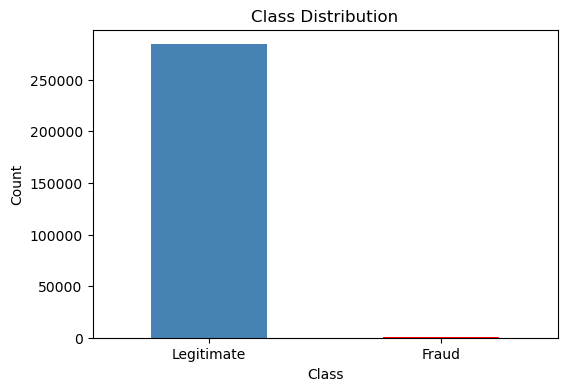

In [3]:
import matplotlib.pyplot as plt

# Class distribution chart
plt.figure(figsize=(6, 4))
df['Class'].value_counts().plot(kind='bar', 
                                 color=['steelblue', 'red'])
plt.title('Class Distribution')
plt.xticks([0, 1], ['Legitimate', 'Fraud'], rotation=0)
plt.ylabel('Count')
plt.savefig('class_dist.png')
plt.show()

In [4]:
# Amount analysis — fraud kis range mein hota hai?
print("Fraud transactions — Amount:")
print(df[df['Class']==1]['Amount'].describe())

print("\nLegit transactions — Amount:")
print(df[df['Class']==0]['Amount'].describe())

Fraud transactions — Amount:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Legit transactions — Amount:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


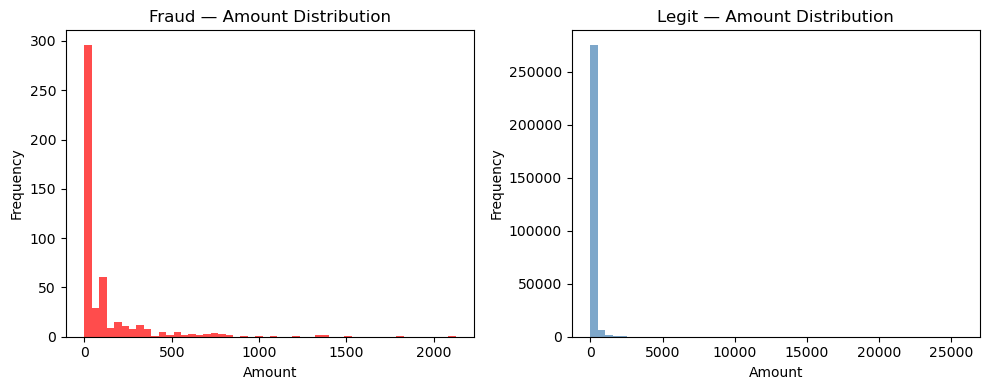

In [5]:
import seaborn as sns

plt.figure(figsize=(10, 4))

# Fraud amount distribution
plt.subplot(1, 2, 1)
df[df['Class']==1]['Amount'].plot(kind='hist', 
                                   bins=50, 
                                   color='red', 
                                   alpha=0.7)
plt.title('Fraud — Amount Distribution')
plt.xlabel('Amount')

# Legit amount distribution
plt.subplot(1, 2, 2)
df[df['Class']==0]['Amount'].plot(kind='hist', 
                                   bins=50, 
                                   color='steelblue', 
                                   alpha=0.7)
plt.title('Legit — Amount Distribution')
plt.xlabel('Amount')

plt.tight_layout()
plt.savefig('amount_distribution.png')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Amount and time scaling
scaler_amount = StandardScaler()
scaler_time = StandardScaler()
df['Amount_scaled'] = scaler_amount.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler_time.fit_transform(df[['Time']])

# Features aur target
X = df.drop(['Class', 'Amount', 'Time'], axis=1)
y = df['Class']

# Train test split — stratify preserves the fraud ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, 
    random_state=42, 
    stratify=y)  # stratify = fraud ratio same rakhta hai dono mein

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nFraud in test set:", y_test.sum())
print("Legit in test set:", (y_test==0).sum())

Train size: (227845, 30)
Test size: (56962, 30)

Fraud in test set: 98
Legit in test set: 56864


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Model — class_weight='balanced' IMPORTANT hai
rf = RandomForestClassifier(
    n_estimators=50, 
    class_weight='balanced',  # imbalance handle
    random_state=42,
    n_jobs=-1 
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Results
print(classification_report(y_test, y_pred, 
      target_names=['Legit', 'Fraud']))

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



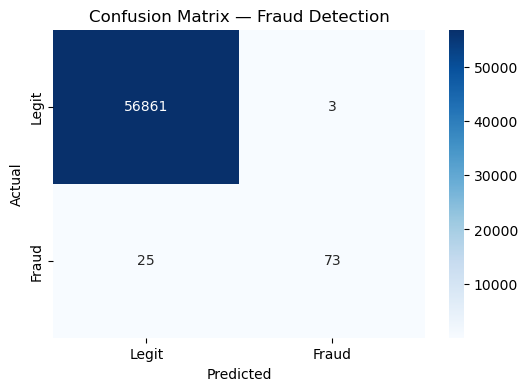

True Positives (Fraud caught): 73
False Negatives (Fraud missed): 25
False Positives (Legit blocked): 3


In [12]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('Confusion Matrix — Fraud Detection')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives (Fraud caught): {tp}")
print(f"False Negatives (Fraud missed): {fn}")
print(f"False Positives (Legit blocked): {fp}")

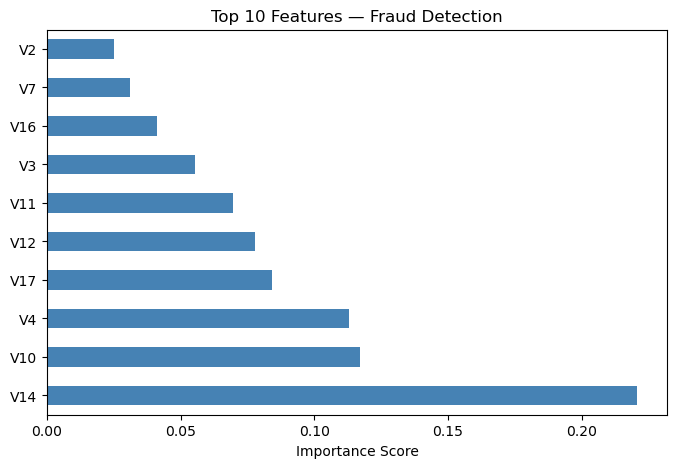

Top 5 features:
V14    0.220877
V10    0.117077
V4     0.113016
V17    0.084101
V12    0.077829
dtype: float64


In [13]:
# fraud detecttion
feat_imp = pd.Series(rf.feature_importances_, 
                     index=X.columns)

plt.figure(figsize=(8, 5))
feat_imp.nlargest(10).plot(kind='barh', color='steelblue')
plt.title('Top 10 Features — Fraud Detection')
plt.xlabel('Importance Score')
plt.savefig('feature_importance.png')
plt.show()

print("Top 5 features:")
print(feat_imp.nlargest(5))